<a href="https://colab.research.google.com/github/SIDDH4RTH245/nlp-sentiment-analysis-project/blob/main/notebooks/05_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 5: Model Evaluation

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df = pd.read_csv("/content/imdb_processed.csv")

X = df["cleaned_review"]
y = df["sentiment"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [4]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

preds = model.predict(X_test_tfidf)

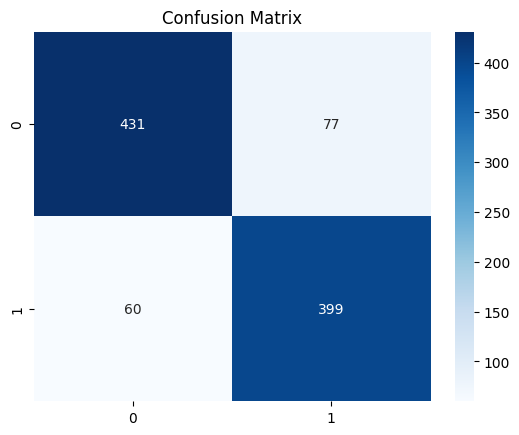

In [6]:
cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [7]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86       508
           1       0.84      0.87      0.85       459

    accuracy                           0.86       967
   macro avg       0.86      0.86      0.86       967
weighted avg       0.86      0.86      0.86       967

